In [70]:
# temporary imports (should be included in next image iteration)
!pip install matplotlib
!pip install pandas

In [32]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [33]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [34]:
FREESOUND_API_KEY = ""
with open("../fsk.env", "r") as f:
    FREESOUND_API_KEY = f.read().split("=")[1]
    FREESOUND_API_KEY = FREESOUND_API_KEY.replace("\n", "").replace('"','')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [40]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [35]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [119]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "ping pong",
        "filter": None,
        "num_results": 20,
    },
]

In [120]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            client=client,
            fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 105344
[2/20] Downloading sound ID 149732
[3/20] Downloading sound ID 17624
[4/20] Downloading sound ID 242044
[5/20] Downloading sound ID 114249
[6/20] Downloading sound ID 729078
[7/20] Downloading sound ID 444372
[8/20] Downloading sound ID 250688
[9/20] Downloading sound ID 838990
[10/20] Downloading sound ID 785060
[11/20] Downloading sound ID 681774
[12/20] Downloading sound ID 628635
[13/20] Downloading sound ID 729079
[14/20] Downloading sound ID 729077
[15/20] Downloading sound ID 729076
[16/20] Downloading sound ID 729075
[17/20] Downloading sound ID 729074
[18/20] Downloading sound ID 418555
[19/20] Downloading sound ID 414461
[20/20] Downloading sound ID 622626
Saved metadata CSV: ../data/meta/dataset_2026-01-18_19-30-57.csv
Saved query log JSON: ../data/meta/dataset_2026-01-18_19-30-57.json


In [71]:
!ls ../data/meta

dataset_2026-01-12_16-08-56.csv   dataset_2026-01-18_13-58-47.json
dataset_2026-01-12_16-08-56.json  dataset_2026-01-18_18-29-36.csv
dataset_2026-01-18_13-58-47.csv   dataset_2026-01-18_18-29-36.json


In [78]:
delete_dataset_with_gc(META_DIR + "dataset_2026-01-18_18-29-36.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-01-18_18-29-36.csv
Deleted query file: /workspace/data/meta/dataset_2026-01-18_18-29-36.json
Deleted audio: /workspace/data/audio/540002_11959822-hq.ogg
Deleted audio: /workspace/data/audio/343168_6071037-hq.ogg
Deleted audio: /workspace/data/audio/514404_1738686-hq.ogg
Deleted audio: /workspace/data/audio/392116_245603-hq.ogg
Deleted audio: /workspace/data/audio/337575_1490240-hq.ogg
Deleted audio: /workspace/data/audio/353692_1431924-hq.ogg
Deleted audio: /workspace/data/audio/772883_6753194-hq.ogg
Deleted audio: /workspace/data/audio/485041_9453283-hq.ogg
Deleted audio: /workspace/data/audio/722412_1490240-hq.ogg
Deleted audio: /workspace/data/audio/244231_4463962-hq.ogg
Deleted audio: /workspace/data/audio/823211_17278148-hq.ogg
Deleted audio: /workspace/data/audio/238919_3406193-hq.ogg
Deleted audio: /workspace/data/audio/267221_3112522-hq.ogg
Deleted audio: /workspace/data/audio/424845_8508138-hq.ogg
Deleted audio: /workspa

### Show downloaded audio

In [121]:
!ls -lt ../data/audio | head -20

total 8736
-rw-r--r-- 1 root root 175996 Jan 18 19:31 622626_593131-hq.ogg
-rw-r--r-- 1 root root 187305 Jan 18 19:31 414461_1738686-hq.ogg
-rw-r--r-- 1 root root 120987 Jan 18 19:31 418555_8333239-hq.ogg
-rw-r--r-- 1 root root 144206 Jan 18 19:31 729074_10725617-hq.ogg
-rw-r--r-- 1 root root 162025 Jan 18 19:31 729075_10725617-hq.ogg
-rw-r--r-- 1 root root 193593 Jan 18 19:31 729076_10725617-hq.ogg
-rw-r--r-- 1 root root 112351 Jan 18 19:31 729077_10725617-hq.ogg
-rw-r--r-- 1 root root 133347 Jan 18 19:30 729079_10725617-hq.ogg
-rw-r--r-- 1 root root 145698 Jan 18 19:30 628635_9129912-hq.ogg
-rw-r--r-- 1 root root  49454 Jan 18 19:30 681774_14331083-hq.ogg
-rw-r--r-- 1 root root  12362 Jan 18 19:30 785060_16787631-hq.ogg
-rw-r--r-- 1 root root  83169 Jan 18 19:30 838990_15636277-hq.ogg
-rw-r--r-- 1 root root  63447 Jan 18 19:30 250688_2271450-hq.ogg
-rw-r--r-- 1 root root 139506 Jan 18 19:30 444372_4636389-hq.ogg
-rw-r--r-- 1 root root  91667 Jan 18 19:30 729078_10725617-hq.ogg
-rw-r-

In [138]:
# select a file manually
filename = "17624_6448-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/17624_6448-hq.ogg'

In [90]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/7913_8043-hq.ogg'

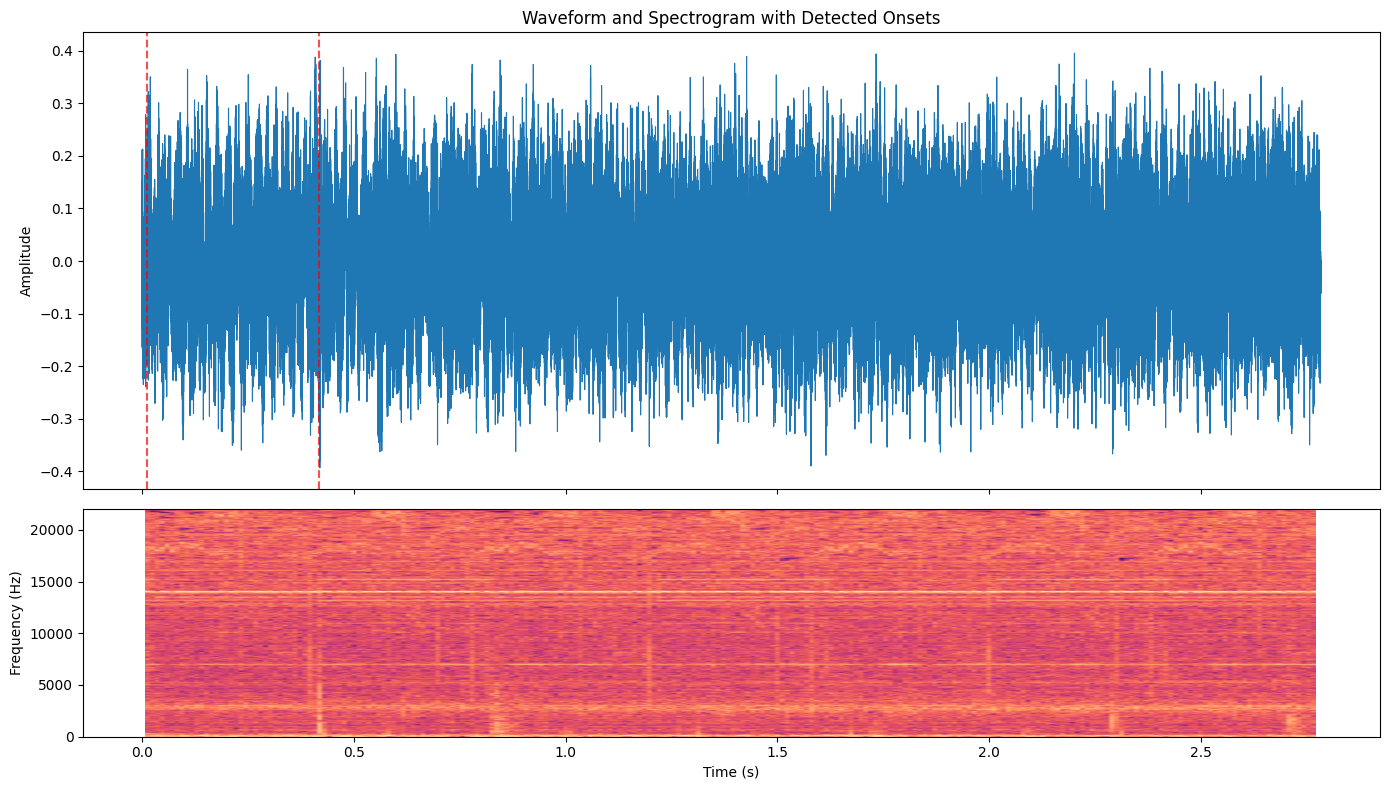

In [139]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)